In [1]:
import pandas as pd
df= pd.read_csv('D:\Project_3\data\HR-Employee-Attrition.csv')

In [2]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [19]:
def attrtion_risk (row):
    if row['JobSatisfaction']<=2 and row['OverTime']=='Yes':
        return 'high risk'
    elif row['JobSatisfaction']<=3:
        return 'medium rish'
    else :
        return 'low risk'
df['attrtion_risk']=df.apply( attrtion_risk, axis=1)
         

df["attrition_risk"].value_counts()



attrition_risk
Medium Risk    858
Low Risk       459
High Risk      153
Name: count, dtype: int64

In [32]:
def productivity_risk(row):
    if row["PerformanceRating"] <= 1 and row["JobSatisfaction"] <= 2:
        return "High Risk"
    elif row["PerformanceRating"] <= 3 and row["JobSatisfaction"] <= 3:
        return "Medium Risk"
    else:
        return "Low Risk"

df["productivity_risk"] = df.apply(productivity_risk, axis=1)
df["productivity_risk"].value_counts()


productivity_risk
Medium Risk    864
Low Risk       606
Name: count, dtype: int64

In [33]:
pd.crosstab(
    df["productivity_risk"],
    df["Attrition"],
    margins=True
)

Attrition,No,Yes,All
productivity_risk,,,
Low Risk,524,82,606
Medium Risk,709,155,864
All,1233,237,1470


In [34]:
attrition_rate = (
    pd.crosstab(df["productivity_risk"], df["Attrition"], normalize='index') * 100
)

attrition_rate


Attrition,No,Yes
productivity_risk,,
Low Risk,86.468647,13.531353
Medium Risk,82.060185,17.939815


<Axes: xlabel='productivity_risk'>

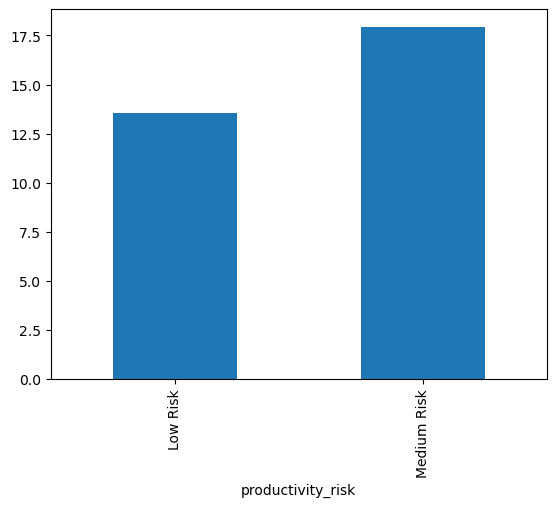

In [35]:
attrition_rate["Yes"].plot(kind="bar")


In [36]:
df[
    (df["PerformanceRating"] <= 2) &
    (df["JobSatisfaction"] <= 2)
][["PerformanceRating", "JobSatisfaction"]].shape


(0, 2)

In [37]:
pd.crosstab(df["PerformanceRating"], df["JobSatisfaction"])


JobSatisfaction,1,2,3,4
PerformanceRating,,,,
3,241,237,386,380
4,48,43,56,79


In [42]:

df.to_csv("project3_hr_final.csv", index=False)
